In [1]:
import os
import pandas as pd
import numpy as np
import importlib
import pickle

from Soccer_OCEL.idsse_import import get_games, load_game_data
from Soccer_OCEL.role_objects import assign_roles_multi
import Soccer_OCEL.utils as utils

from pm4py.objects.ocel.util.log_ocel import log_to_ocel_multiple_obj_types
import pm4py

from pm4py.algo.discovery.dfg.variants import clean_time
from pm4py.visualization.dfg.variants import timeline as timeline_gviz_generator
from pm4py.visualization.dfg import visualizer as dfg_visualizer

In [42]:
#load all
path='data/28196177'
FD='DFL-CLU-00000P'
#games=get_games(path)
games=['J03WQQ', 'J03WR9', 'J03WPY', 'J03WOH', 'J03WOY']#Fortuna Düsseldorf
#games=['J03WQQ', 'J03WOH', 'J03WOY']#Fortuna Düsseldorf, won games
#games=['J03WR9', 'J03WPY']#Fortuna Düsseldorf lost game
GDs=[]
all_games=[]
for Game in games:
    with open(os.path.join('output','output_pkl',f"GameData_{Game}.pkl"), "rb") as f:
        GD_loaded = pickle.load(f)
        GDs.append(GD_loaded)
        #GD_loaded.join_events(log='MOVEMENT')
        GD_loaded=assign_roles_multi(GD_loaded, team=True)
        GD_loaded.encode_pass_distance()
        GD_loaded.format_log()
    all_games.append(GD_loaded.events)
allgame_df=pd.concat(all_games).sort_values(["attribute:game","attribute:session", "attribute:frame"]).reset_index(drop=True)

In [1]:
allgame_df

NameError: name 'allgame_df' is not defined

In [43]:
FD_log=[]
for i, game_log in enumerate(all_games):
    teamside=GDs[i].team_sheets_df.query('tID==@FD')['Home_Away'].values[0]
    #FD_log.append(game_log.query('tID==@FD'))
    FD_log.append(game_log[game_log['case:concept:name'].str.contains(teamside, na=False)])
    #FD_log.append(game_log[(game_log['tID'] == FD) & (game_log['case:concept:name'].str.contains(teamside, na=False))])
allgame_df=pd.concat(FD_log).sort_values(["attribute:game","attribute:session", "attribute:frame"]).reset_index(drop=True)

In [45]:
event_log = pm4py.convert_to_event_log(allgame_df)
variants = pm4py.get_variants(event_log)

In [66]:
keys = list(variants.keys())
frequency = [len(variants[k]) for k in keys]

order = np.argsort(frequency)[::-1]  # descending order

keys_sorted = [keys[i] for i in order]
freq_sorted = [frequency[i] for i in order]

k = 20
for i in range(k):
    print(f"{i+1} most frequent variant: {freq_sorted[i]} times")
    print(keys_sorted[i])

1 most frequent variant: 41 times
('Pass_Intercepted',)
2 most frequent variant: 25 times
('TacklingGame',)
3 most frequent variant: 20 times
('Pass_Intercepted', 'OtherBallAction')
4 most frequent variant: 17 times
('Pass_Intercepted', 'OtherBallAction', 'TacklingGame')
5 most frequent variant: 14 times
('Pass_Intercepted', 'TacklingGame', 'OtherBallAction')
6 most frequent variant: 14 times
('Pass_Intercepted', 'Play_Pass_medium', 'Ball_lost')
7 most frequent variant: 12 times
('ThrowIn_Play_Pass', 'Ball_lost')
8 most frequent variant: 12 times
('Pass_Intercepted', 'Play_Pass_long', 'Ball_lost')
9 most frequent variant: 12 times
('FreeKick_Play_Pass', 'Ball_lost')
10 most frequent variant: 10 times
('GoalKick_Play_Pass', 'Ball_lost')
11 most frequent variant: 9 times
('CornerKick_Play_Cross', 'Ball_lost')
12 most frequent variant: 7 times
('TacklingGame', 'Foul')
13 most frequent variant: 7 times
('ThrowIn_Play_Cross', 'Ball_lost')
14 most frequent variant: 6 times
('ThrowIn_Play_Pas

In [ ]:
#filters on the top-k variants retain only the cases following one of the k most frequent variants
k = 2
filtered_log = pm4py.filter_variants_top_k(event_log, k)

In [64]:
from pm4py.statistics.start_activities.log import get as start_get
from pm4py.statistics.end_activities.log import get as end_get
event_log = pm4py.convert_to_event_log(allgame_df)
start_activities = start_get.get_start_activities(event_log)
#end_activities = end_get.get_end_activities(event_log)
start_activities#, end_activities


{'OtherBallAction': 17,
 'Cross_Intercepted': 40,
 'GoalKick_Play_Pass': 40,
 'Pass_Intercepted': 376,
 'ThrowIn_Play_Pass': 102,
 'BallClaiming': 70,
 'TacklingGame': 61,
 'FreeKick_Play_Pass': 60,
 'FreeKick_Play_Cross': 5,
 'Play_Cross_medium': 1,
 'Play_Pass_long': 1,
 'CornerKick_Play_Cross': 16,
 'Play_Pass_short': 2,
 'Penalty_ShotAtGoal': 1,
 'SpectacularPlay': 1,
 'KickOff_Play_Pass': 5,
 'PenaltyNotAwarded': 2,
 'Play_Pass_medium': 2,
 'OutSubstitution': 4,
 'FairPlay': 2,
 'CornerKick_Play_Pass': 3,
 'ThrowIn_Play_Cross': 10,
 'ThrowIn': 1,
 'FreeKick_ShotAtGoal': 1,
 'VideoAssistantAction': 1}

In [8]:
allgame_df=utils.add_pass_cross_sequences(allgame_df)

/Users/vitochan/Documents/phd/Projects/Soccer/Soccer_OCEL/utils.py:226: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_action = df['concept:name'].str.contains(r'(pass|cross)', case=False, na=False)
/Users/vitochan/Documents/phd/Projects/Soccer/Soccer_OCEL/utils.py:227: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_excluded = df['concept:name'].str.contains(r'(received|intercepted)', case=False, na=False)


In [20]:
shot_events=allgame_df[(allgame_df['concept:name'].str.contains('Shot'))
                       &allgame_df['attribute:team'].str.contains('Home')
                       &(allgame_df['attribute:outcome']==0)
                         ]
shot_df = allgame_df[allgame_df['case:concept:name'].isin(shot_events['case:concept:name'])]
# end=shot_df[(shot_df['concept:name'].str.contains('Wide'))
#                           ]
# shot_df = shot_df[shot_df['case:concept:name'].isin(end['case:concept:name'])]
shot_df=utils.filter_players_involved_with_ball(shot_df)

event_log = pm4py.convert_to_event_log(shot_df)

/Users/vitochan/Documents/phd/Projects/Soccer/.venv/lib/python3.11/site-packages/pm4py/visualization/dfg/variants/timeline.py:273: UserWarning: Data alignment issue: 'OtherBallAction' does not have a corresponding timestamp or second element. Ensure each activity is properly matched with a timestamp.
  warnings.warn(f"Data alignment issue: '{values}' does not have a corresponding timestamp or second element. Ensure each activity is properly matched with a timestamp.")
/Users/vitochan/Documents/phd/Projects/Soccer/.venv/lib/python3.11/site-packages/pm4py/visualization/dfg/variants/timeline.py:273: UserWarning: Data alignment issue: 'GoalKick_Play_Pass' does not have a corresponding timestamp or second element. Ensure each activity is properly matched with a timestamp.
  warnings.warn(f"Data alignment issue: '{values}' does not have a corresponding timestamp or second element. Ensure each activity is properly matched with a timestamp.")


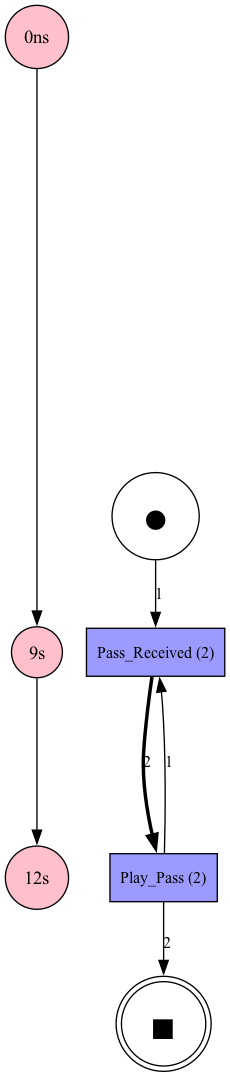

In [21]:
#log = shot_df[~shot_df['Forward'].isna()]
#log = shot_df[~shot_df['Midfielder'].isna()]
#log = shot_df[~shot_df['Defender'].isna()]
log = shot_df[~shot_df['Goalkeeper'].isna()]
#log=shot_df
dfg, start_act, end_act = pm4py.discover_dfg_typed(log)
dfg_time = clean_time.apply(log, parameters={"aggregation": "mean"})
gviz = timeline_gviz_generator.apply(dfg, dfg_time, parameters={"format": "png", "start_activities": start_act,
                                                                    "end_activities": end_act})
dfg_visualizer.view(gviz)

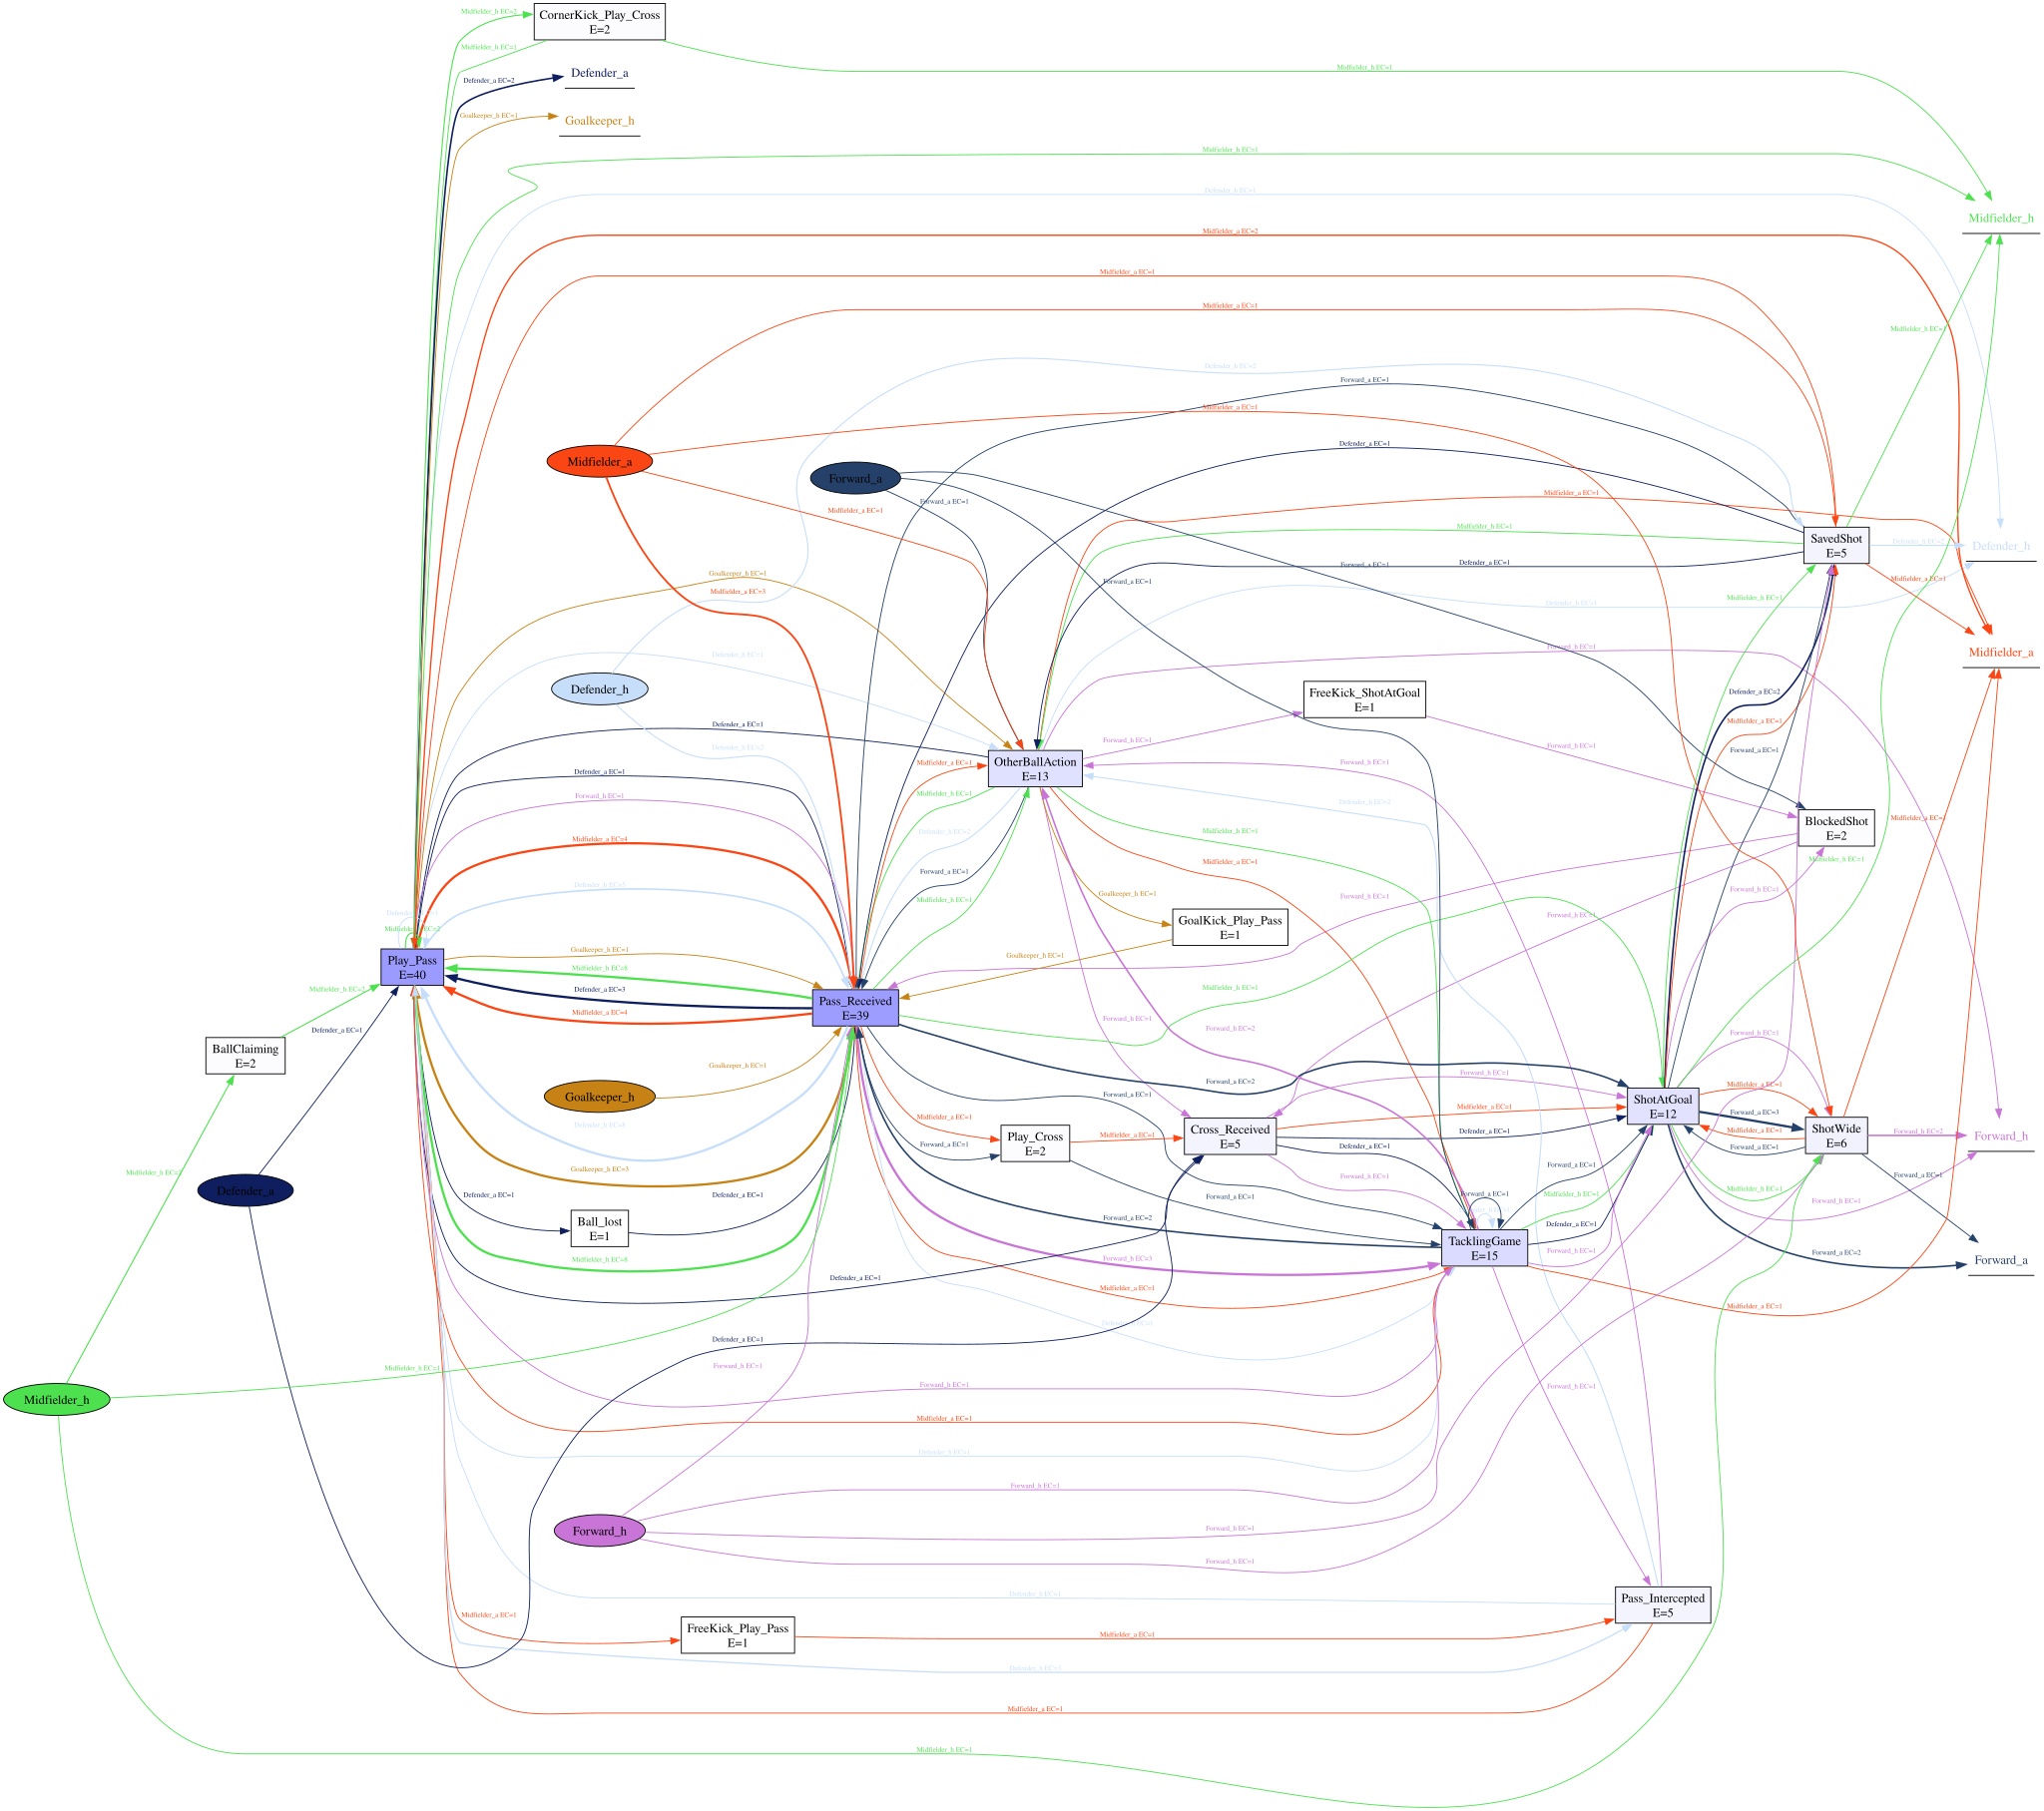

In [22]:
# convert to ocel
ocel= log_to_ocel_multiple_obj_types(event_log, activity_column='concept:name'
                                        , timestamp_column='time:timestamp'
                                        , obj_types=[#'case:concept:name'
                                                     #'attacking_team', 'defending_team'
                                                     #'ball',
                                                     "Forward_h", "Midfielder_h", "Defender_h", "Goalkeeper_h"
                                                     ,"Forward_a", "Midfielder_a", "Defender_a", "Goalkeeper_a"
                                                     #,'Team','Player','Session', 'case:concept:name'
                                                     ]
                                        ,additional_event_attributes=['attribute:enabled'
                                                                    , 'attribute:x', 'attribute:y'
                                                                    , 'attribute:session', 'attribute:team'
                                                                    ])
dfg=pm4py.ocel.discover_ocdfg(ocel,business_hours=True)
pm4py.visualization.ocel.ocdfg.visualizer.apply(dfg)

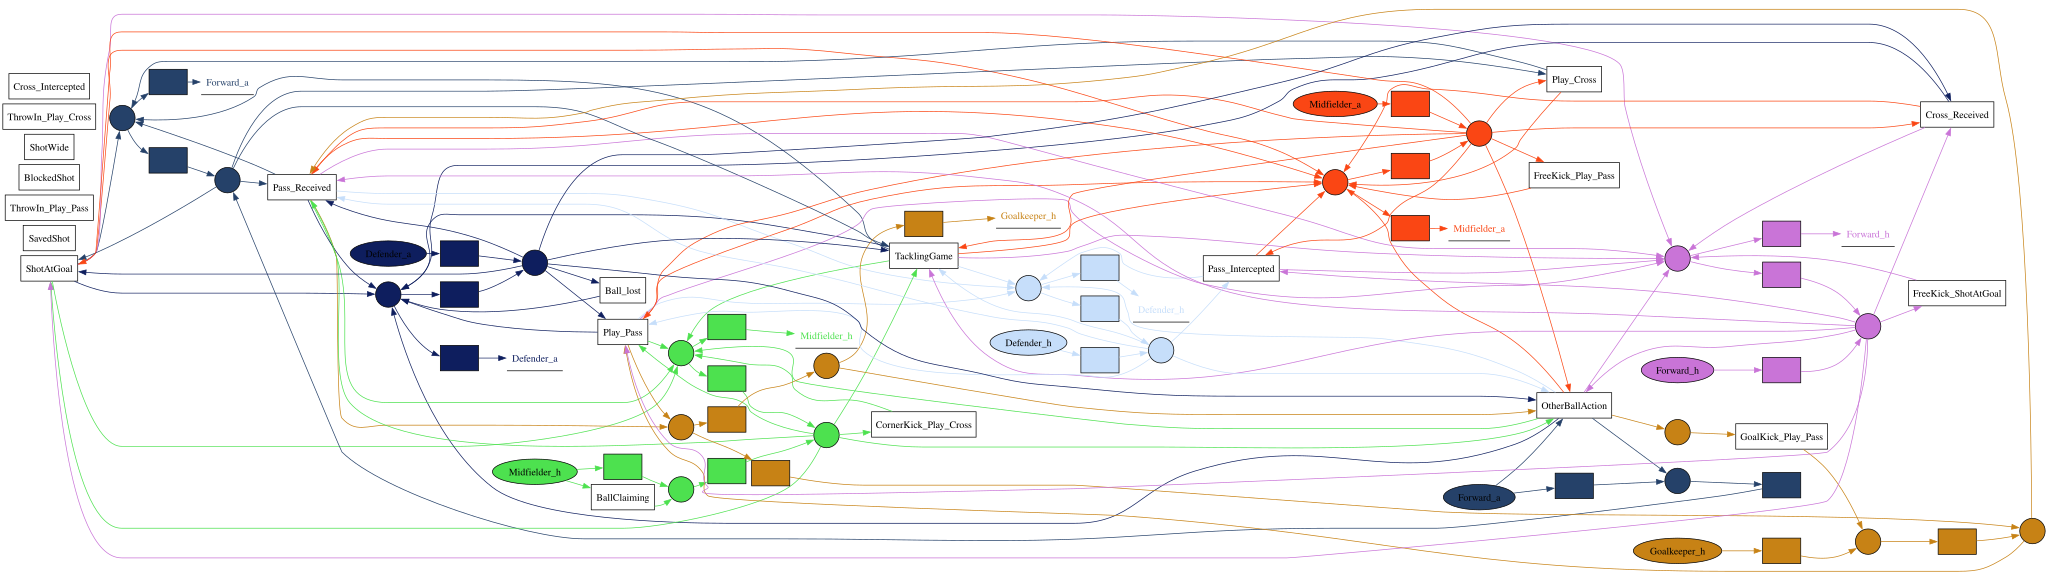

In [23]:
pn=pm4py.ocel.discover_oc_petri_net(ocel)
pm4py.visualization.ocel.ocpn.visualizer.apply(pn)